# Kenya Food Security Data Analysis

This notebook analyzes Kenya food security data from two sources:

- FAOSTAT food security datasets from HDX for national-level trends.
- World Bank Joint Food Security Monitor (JMR) data for county and sub-county food security risk mapping.

The workflow uses Pandas for cleaning and `pd.merge`, Matplotlib/Seaborn for statistics and charts, and GeoPandas for map-ready county visualizations.


## Project Questions

1. What national food security and healthy diet affordability trends are visible in the FAOSTAT data?
2. Which counties show higher food security risk in the World Bank JMR data?
3. How can the JMR admin-2 data be aggregated to counties and joined to county boundaries?
4. What visualizations best communicate the national trend and county risk patterns?


In [ ]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

DATA_DIR = Path("data")
JMR_DIR = DATA_DIR / "world_bank_jmr"
SHAPEFILE_DIR = DATA_DIR / "shapefiles"

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

## 1. Load FAOSTAT / HDX National Data


In [ ]:
food_security = pd.read_csv(DATA_DIR / "ken_faostat_food_security_indicators.csv")
food_balances = pd.read_csv(DATA_DIR / "ken_faostat_food_balances.csv")
healthy_diet = pd.read_csv(DATA_DIR / "ken_faostat_cost_affordability_healthy_diet.csv")

datasets = {
    "food_security": food_security,
    "food_balances": food_balances,
    "healthy_diet": healthy_diet,
}

for name, df in datasets.items():
    print(f"{name}: {df.shape[0]:,} rows x {df.shape[1]:,} columns")
    display(df.head(3))

food_security: 1,127 rows x 16 columns


,Iso3,StartDate,EndDate,Area Code,Area Code (M49),Area,Item Code,Item,Element Code,Element,Year Code,Year,Unit,Value,Flag,Note
0,KEN,2000-01-01,2002-12-31,114,'404,Kenya,21010,Average dietary energy supply adequacy (percen...,6121,Value,20002002,2002,%,93.0,E,NaN
1,KEN,2001-01-01,2003-12-31,114,'404,Kenya,21010,Average dietary energy supply adequacy (percen...,6121,Value,20012003,2003,%,92.0,E,NaN
2,KEN,2002-01-01,2004-12-31,114,'404,Kenya,21010,Average dietary energy supply adequacy (percen...,6121,Value,20022004,2004,%,92.0,E,NaN


food_balances: 25,330 rows x 17 columns


,Iso3,StartDate,EndDate,Area Code,Area Code (M49),Area,Item Code,Item Code (FBS),Item,Element Code,Element,Year Code,Year,Unit,Value,Flag,Note
0,KEN,2010-01-01,2010-12-31,114,'404,Kenya,2501,'S2501,Population,511,Total Population - Both sexes,2010,2010,1000 No,41598.57,X,NaN
1,KEN,2011-01-01,2011-12-31,114,'404,Kenya,2501,'S2501,Population,511,Total Population - Both sexes,2011,2011,1000 No,42758.46,X,NaN
2,KEN,2012-01-01,2012-12-31,114,'404,Kenya,2501,'S2501,Population,511,Total Population - Both sexes,2012,2012,1000 No,43888.30,X,NaN


healthy_diet: 48 rows x 17 columns


,Iso3,StartDate,EndDate,Area Code,Area Code (M49),Area,Item Code,Item,Element Code,Element,Year Code,Year,Release Code,Release,Unit,Value,Flag
0,KEN,2017-01-01,2017-12-31,114,'404,Kenya,70040,Cost of a healthy diet (CoHD),6226,Value,2017,2017,7S2026,July 2026 (SOFI report),Int$ (PPP) per person per day,2.56,E
1,KEN,2018-01-01,2018-12-31,114,'404,Kenya,70040,Cost of a healthy diet (CoHD),6226,Value,2018,2018,7S2026,July 2026 (SOFI report),Int$ (PPP) per person per day,2.62,E
2,KEN,2019-01-01,2019-12-31,114,'404,Kenya,70040,Cost of a healthy diet (CoHD),6226,Value,2019,2019,7S2026,July 2026 (SOFI report),Int$ (PPP) per person per day,2.83,E


In [ ]:
coverage = []
for name, df in datasets.items():
    coverage.append({
        "dataset": name,
        "rows": len(df),
        "columns": df.shape[1],
        "min_year": int(df["Year"].min()),
        "max_year": int(df["Year"].max()),
        "unique_items": df["Item"].nunique(),
        "unique_units": df["Unit"].nunique(),
    })

display(pd.DataFrame(coverage))

,dataset,rows,columns,min_year,max_year,unique_items,unique_units
0,food_security,1127,16,2000,2025,47,7
1,food_balances,25330,17,2010,2023,119,7
2,healthy_diet,48,17,2017,2025,9,4


## 2. Clean and Reshape FAOSTAT Indicators

The FAOSTAT files are long tables, so selected indicators are pivoted into a year-level table for Kenya.


In [30]:
def clean_base(df):
    cleaned = df.copy()
    cleaned.columns = cleaned.columns.str.strip()
    cleaned["Year"] = pd.to_numeric(cleaned["Year"], errors="coerce").astype("Int64")
    cleaned["Value"] = pd.to_numeric(cleaned["Value"], errors="coerce")
    cleaned["Area"] = cleaned["Area"].astype(str).str.strip()
    cleaned["Iso3"] = cleaned["Iso3"].astype(str).str.strip()
    return cleaned

food_security_clean = clean_base(food_security)
food_balances_clean = clean_base(food_balances)
healthy_diet_clean = clean_base(healthy_diet)

KEYS = ["Iso3", "Area", "Year"]

In [5]:
def pivot_indicators(df, item_map, value_col="Value"):
    selected = df[df["Item"].isin(item_map.keys())].copy()
    selected["indicator"] = selected["Item"].map(item_map)
    wide = (
        selected
        .pivot_table(index=KEYS, columns="indicator", values=value_col, aggfunc="mean")
        .reset_index()
    )
    wide.columns.name = None
    return wide

food_security_items = {
    "Average dietary energy supply adequacy (percent) (3-year average)": "dietary_energy_adequacy_pct",
    "Prevalence of undernourishment (percent) (3-year average)": "undernourishment_pct",
    "Number of people undernourished (million) (3-year average)": "undernourished_people_million",
    "Prevalence of severe food insecurity in the total population (percent) (3-year average)": "severe_food_insecurity_pct",
    "Prevalence of moderate or severe food insecurity in the total population (percent) (3-year average)": "moderate_or_severe_food_insecurity_pct",
    "Percentage of children under 5 years of age who are stunted (modelled estimates) (percent)": "under5_stunting_pct",
    "Percentage of children under 5 years affected by wasting (percent)": "under5_wasting_pct",
    "Gross domestic product per capita, PPP, (constant 2021 international $)": "gdp_per_capita_ppp",
}

healthy_diet_items = {
    "Cost of a healthy diet (CoHD)": "healthy_diet_cost_ppp_per_day",
    "Prevalence of unaffordability (PUA)": "healthy_diet_unaffordable_pct",
    "Number of people unable to afford a healthy diet (NUA)": "people_unable_afford_healthy_diet_million",
}

fsi_wide = pivot_indicators(food_security_clean, food_security_items)
cohd_wide = pivot_indicators(healthy_diet_clean, healthy_diet_items)

display(fsi_wide.head())
display(cohd_wide.head())


,Iso3,Area,Year,dietary_energy_adequacy_pct,gdp_per_capita_ppp,moderate_or_severe_food_insecurity_pct,severe_food_insecurity_pct,under5_stunting_pct,under5_wasting_pct,undernourished_people_million,undernourishment_pct
0,KEN,Kenya,2000,NaN,3757.0,NaN,NaN,38.6,7.4,NaN,NaN
1,KEN,Kenya,2001,NaN,3778.0,NaN,NaN,38.5,NaN,NaN,NaN
2,KEN,Kenya,2002,93.0,3681.0,NaN,NaN,38.5,NaN,10.1,31.8
3,KEN,Kenya,2003,92.0,3674.0,NaN,NaN,38.2,6.2,10.9,33.3
4,KEN,Kenya,2004,92.0,3744.0,NaN,NaN,37.8,NaN,11.6,34.5


,Iso3,Area,Year,healthy_diet_cost_ppp_per_day,healthy_diet_unaffordable_pct,people_unable_afford_healthy_diet_million
0,KEN,Kenya,2017,57.180,69.8,34.3
1,KEN,Kenya,2018,57.990,69.8,35.1
2,KEN,Kenya,2019,62.695,72.1,36.9
3,KEN,Kenya,2020,68.420,76.3,39.8
4,KEN,Kenya,2021,74.265,78.0,41.5


## 3. Prepare FAOSTAT Food Balance Indicators


In [6]:
population = (
    food_balances_clean[
        (food_balances_clean["Item"] == "Population")
        & (food_balances_clean["Element"] == "Total Population - Both sexes")
    ][KEYS + ["Value"]]
    .rename(columns={"Value": "population_thousand"})
)

food_supply = (
    food_balances_clean[
        (food_balances_clean["Item"] == "Grand Total")
        & (food_balances_clean["Element"] == "Food supply (kcal/capita/day)")
    ][KEYS + ["Value"]]
    .rename(columns={"Value": "food_supply_kcal_capita_day"})
)

protein_supply = (
    food_balances_clean[
        (food_balances_clean["Item"] == "Grand Total")
        & (food_balances_clean["Element"] == "Protein supply quantity (g/capita/day)")
    ][KEYS + ["Value"]]
    .rename(columns={"Value": "protein_supply_g_capita_day"})
)

fat_supply = (
    food_balances_clean[
        (food_balances_clean["Item"] == "Grand Total")
        & (food_balances_clean["Element"] == "Fat supply quantity (g/capita/day)")
    ][KEYS + ["Value"]]
    .rename(columns={"Value": "fat_supply_g_capita_day"})
)

food_balance_wide = population.merge(food_supply, on=KEYS, how="outer")
food_balance_wide = food_balance_wide.merge(protein_supply, on=KEYS, how="outer")
food_balance_wide = food_balance_wide.merge(fat_supply, on=KEYS, how="outer")

display(food_balance_wide.head())


,Iso3,Area,Year,population_thousand,food_supply_kcal_capita_day,protein_supply_g_capita_day,fat_supply_g_capita_day
0,KEN,Kenya,2010,41598.57,2178.21,57.79,54.08
1,KEN,Kenya,2011,42758.46,2185.37,60.58,44.99
2,KEN,Kenya,2012,43888.30,2208.06,60.39,44.23
3,KEN,Kenya,2013,44986.79,2233.44,59.13,54.12
4,KEN,Kenya,2014,46051.44,2230.33,60.45,45.25


## 4. Merge FAOSTAT National Analysis Table

The FAOSTAT tables share `Iso3`, `Area`, and `Year`, so they can be joined using `pd.merge`.


In [7]:
analysis_df = fsi_wide.merge(food_balance_wide, on=KEYS, how="outer")
analysis_df = analysis_df.merge(cohd_wide, on=KEYS, how="outer")
analysis_df = analysis_df.sort_values("Year").reset_index(drop=True)

print(analysis_df.shape)
display(analysis_df.head())
display(analysis_df.tail())


(26, 18)


,Iso3,Area,Year,dietary_energy_adequacy_pct,gdp_per_capita_ppp,moderate_or_severe_food_insecurity_pct,severe_food_insecurity_pct,under5_stunting_pct,under5_wasting_pct,undernourished_people_million,undernourishment_pct,population_thousand,food_supply_kcal_capita_day,protein_supply_g_capita_day,fat_supply_g_capita_day,healthy_diet_cost_ppp_per_day,healthy_diet_unaffordable_pct,people_unable_afford_healthy_diet_million
0,KEN,Kenya,2000,NaN,3757.0,NaN,NaN,38.6,7.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,KEN,Kenya,2001,NaN,3778.0,NaN,NaN,38.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,KEN,Kenya,2002,93.0,3681.0,NaN,NaN,38.5,NaN,10.1,31.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,KEN,Kenya,2003,92.0,3674.0,NaN,NaN,38.2,6.2,10.9,33.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,KEN,Kenya,2004,92.0,3744.0,NaN,NaN,37.8,NaN,11.6,34.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,Iso3,Area,Year,dietary_energy_adequacy_pct,gdp_per_capita_ppp,moderate_or_severe_food_insecurity_pct,severe_food_insecurity_pct,under5_stunting_pct,under5_wasting_pct,undernourished_people_million,undernourishment_pct,population_thousand,food_supply_kcal_capita_day,protein_supply_g_capita_day,fat_supply_g_capita_day,healthy_diet_cost_ppp_per_day,healthy_diet_unaffordable_pct,people_unable_afford_healthy_diet_million
21,KEN,Kenya,2021,97.0,5339.0,69.500000,26.066667,19.2,NaN,15.0,28.8,53219.17,2162.74,55.72,52.38,74.265,78.0,41.5
22,KEN,Kenya,2022,95.0,5492.0,72.266667,28.000000,18.7,4.5,17.8,33.4,54252.46,2137.61,56.54,51.07,83.655,77.8,42.2
23,KEN,Kenya,2023,93.0,5692.0,72.833333,28.033333,18.2,NaN,19.6,36.2,55339.00,2146.01,55.77,48.60,91.730,76.9,42.6
24,KEN,Kenya,2024,93.0,5845.0,73.900000,28.066667,17.9,NaN,20.1,36.4,NaN,NaN,NaN,NaN,96.690,76.4,43.1
25,KEN,Kenya,2025,94.0,NaN,71.733333,26.466667,NaN,NaN,19.7,34.9,NaN,NaN,NaN,NaN,103.525,76.3,43.9


In [8]:
latest_values = []
for col in [c for c in analysis_df.columns if c not in KEYS]:
    latest = analysis_df.dropna(subset=[col]).sort_values("Year").tail(1)
    if not latest.empty:
        latest_values.append({
            "indicator": col,
            "latest_year": int(latest["Year"].iloc[0]),
            "latest_value": latest[col].iloc[0],
        })

latest_df = pd.DataFrame(latest_values).sort_values("indicator")
display(latest_df)


,indicator,latest_year,latest_value
0,dietary_energy_adequacy_pct,2025,94.000000
11,fat_supply_g_capita_day,2023,48.600000
9,food_supply_kcal_capita_day,2023,2146.010000
1,gdp_per_capita_ppp,2024,5845.000000
12,healthy_diet_cost_ppp_per_day,2025,103.525000
13,healthy_diet_unaffordable_pct,2025,76.300000
2,moderate_or_severe_food_insecurity_pct,2025,71.733333
14,people_unable_afford_healthy_diet_million,2025,43.900000
8,population_thousand,2023,55339.000000
10,protein_supply_g_capita_day,2023,55.770000


## 5. National Trend Visualizations


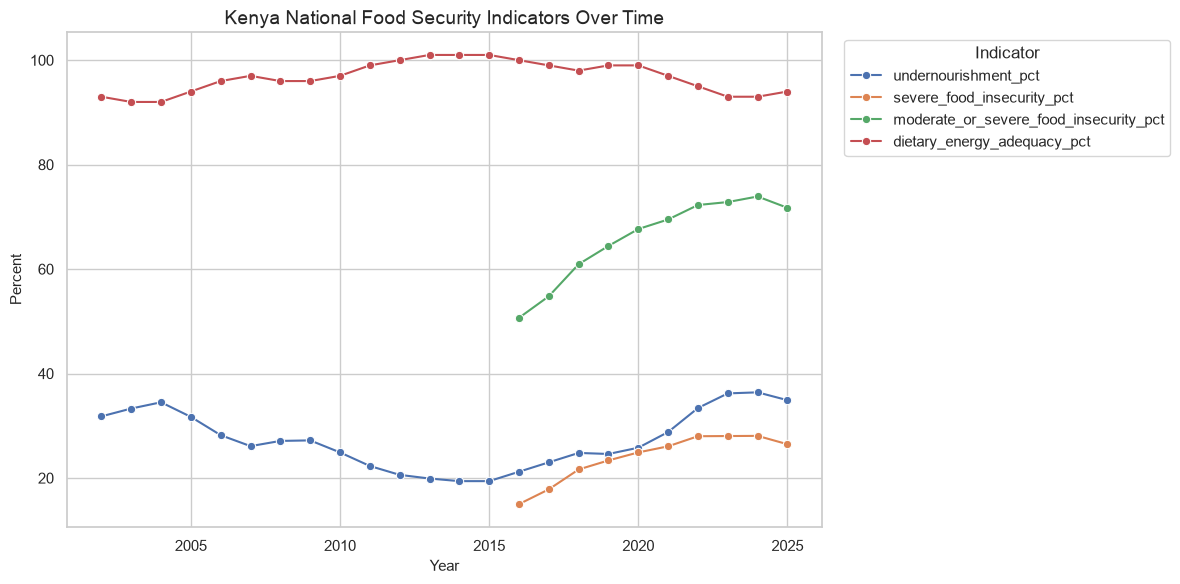

In [9]:
trend_cols = [
    "undernourishment_pct",
    "severe_food_insecurity_pct",
    "moderate_or_severe_food_insecurity_pct",
    "dietary_energy_adequacy_pct",
]

trend_df = analysis_df[["Year"] + trend_cols].melt(
    id_vars="Year",
    var_name="indicator",
    value_name="value",
).dropna()

plt.figure(figsize=(12, 6))
sns.lineplot(data=trend_df, x="Year", y="value", hue="indicator", marker="o")
plt.title("Kenya National Food Security Indicators Over Time")
plt.xlabel("Year")
plt.ylabel("Percent")
plt.legend(title="Indicator", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


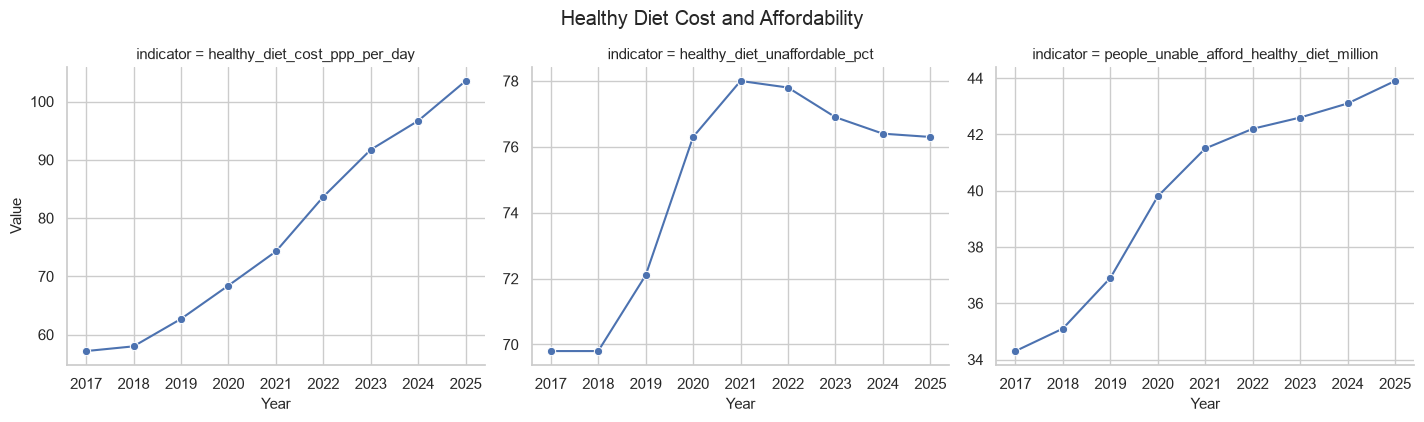

In [10]:
cohd_cols = [
    "healthy_diet_cost_ppp_per_day",
    "healthy_diet_unaffordable_pct",
    "people_unable_afford_healthy_diet_million",
]

cohd_plot_df = analysis_df[["Year"] + cohd_cols].melt(
    id_vars="Year",
    var_name="indicator",
    value_name="value",
).dropna()

g = sns.relplot(
    data=cohd_plot_df,
    x="Year",
    y="value",
    col="indicator",
    kind="line",
    marker="o",
    facet_kws={"sharey": False},
    height=4,
    aspect=1.2,
)
g.fig.suptitle("Healthy Diet Cost and Affordability", y=1.05)
g.set_axis_labels("Year", "Value")
plt.show()


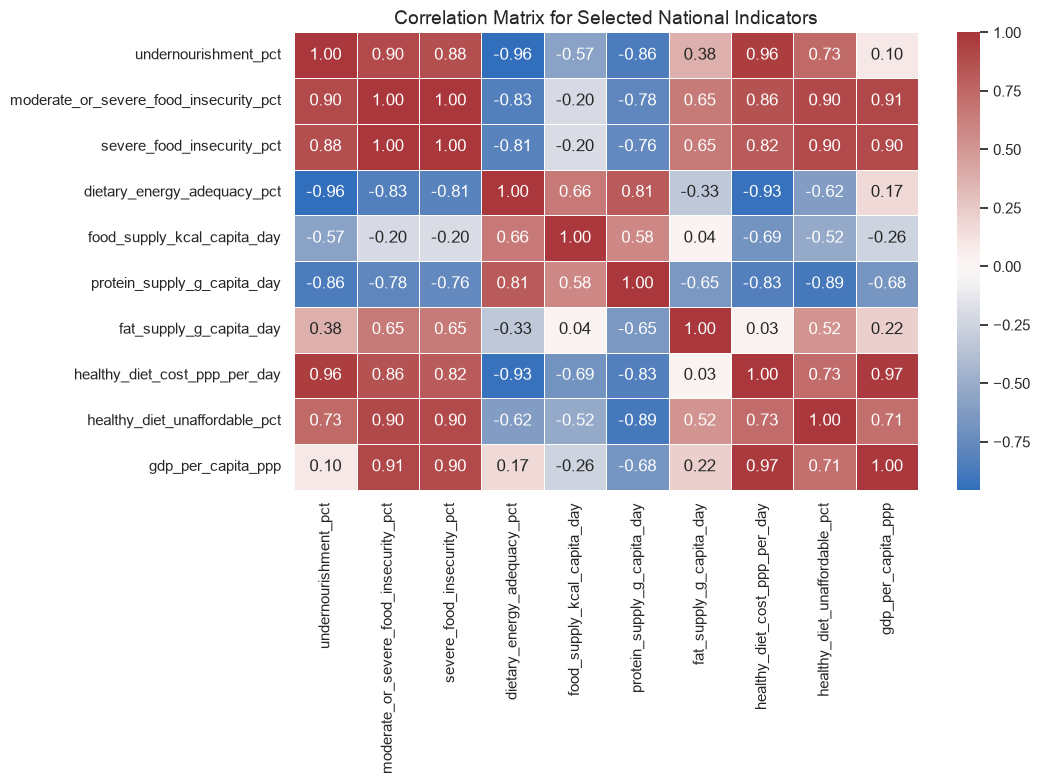

In [11]:
corr_cols = [
    "undernourishment_pct",
    "moderate_or_severe_food_insecurity_pct",
    "severe_food_insecurity_pct",
    "dietary_energy_adequacy_pct",
    "food_supply_kcal_capita_day",
    "protein_supply_g_capita_day",
    "fat_supply_g_capita_day",
    "healthy_diet_cost_ppp_per_day",
    "healthy_diet_unaffordable_pct",
    "gdp_per_capita_ppp",
]

corr = analysis_df[corr_cols].corr(numeric_only=True)
plt.figure(figsize=(11, 8))
sns.heatmap(corr, annot=True, cmap="vlag", center=0, fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix for Selected National Indicators")
plt.tight_layout()
plt.show()


## 6. Load World Bank JMR County/Sub-County Data

The World Bank Joint Food Security Monitor files are stored as zip files and read directly by Pandas.

Useful files:

- `KEN_JMR_data.zip`: monthly admin-2 food security risk indicators.
- `KEN_JMR_pcodes.zip`: lookup table connecting admin-2 pcodes to counties.
- `kenya_counties.geojson`: Kenya county geometries with admin-1 pcodes.


In [12]:
jmr_data = pd.read_csv(
    JMR_DIR / "KEN_JMR_data.zip",
    parse_dates=["date"],
)

jmr_pcodes = pd.read_csv(JMR_DIR / "KEN_JMR_pcodes.zip")

print("JMR data:", jmr_data.shape)
print("JMR pcodes:", jmr_pcodes.shape)
display(jmr_data.head())
display(jmr_pcodes.head())


JMR data: (1517890, 9)
JMR pcodes: (290, 7)


,iso3,ipc phase cutoff,adm2_pcode,year,month,indicator,grouping,value,date
0,KEN,3,KE001001,2010,1,Target,Original IPC phase,3.0,2010-01-01
1,KEN,3,KE001001,2010,4,Target,Original IPC phase,2.0,2010-04-01
2,KEN,3,KE001001,2010,7,Target,Original IPC phase,2.0,2010-07-01
3,KEN,3,KE001001,2010,10,Target,Original IPC phase,2.0,2010-10-01
4,KEN,3,KE001001,2011,1,Target,Original IPC phase,2.0,2011-01-01


,iso3,adm0_pcode,country,adm1_pcode,adm1_name,adm2_pcode,adm2_name
0,KEN,KEN,Kenya,KE001,Mombasa,KE001001,Changamwe
1,KEN,KEN,Kenya,KE001,Mombasa,KE001002,Jomvu
2,KEN,KEN,Kenya,KE001,Mombasa,KE001003,Kisauni
3,KEN,KEN,Kenya,KE001,Mombasa,KE001004,Nyali
4,KEN,KEN,Kenya,KE001,Mombasa,KE001005,Likoni


In [13]:
print("JMR date range:", jmr_data["date"].min(), "to", jmr_data["date"].max())
print("Admin-2 areas:", jmr_data["adm2_pcode"].nunique())
print("Counties in lookup:", jmr_pcodes["adm1_name"].nunique())

display(
    jmr_data.groupby(["indicator", "grouping"])
    .size()
    .reset_index(name="rows")
    .sort_values(["indicator", "grouping"])
)


JMR date range: 2010-01-01 00:00:00 to 2026-07-01 00:00:00
Admin-2 areas: 290
Counties in lookup: 47


,indicator,grouping,rows
0,Conflict,Alert level,57710
1,Conflict,Indicator value,57710
2,Conflict,Original value,57710
3,Drought - NDVI,Alert level,57710
4,Drought - NDVI,Indicator value,57710
5,Drought - NDVI,Original value,57710
6,Drought - rainfall,Alert level,57710
7,Drought - rainfall,Indicator value,57710
8,Drought - rainfall,Original value,57710
9,Exchange rates,Alert level,57710


## 7. Join JMR Data to County Lookup with `pd.merge`

The main JMR data is keyed by `adm2_pcode`. The lookup table adds county names and county pcodes through `adm1_name` and `adm1_pcode`.


In [14]:
jmr_admin = jmr_data.merge(
    jmr_pcodes[["adm1_pcode", "adm1_name", "adm2_pcode", "adm2_name"]],
    on="adm2_pcode",
    how="left",
)

print(jmr_admin.shape)
print("Rows missing county lookup:", jmr_admin["adm1_name"].isna().sum())
display(jmr_admin.head())


(1517890, 12)
Rows missing county lookup: 0


,iso3,ipc phase cutoff,adm2_pcode,year,month,indicator,grouping,value,date,adm1_pcode,adm1_name,adm2_name
0,KEN,3,KE001001,2010,1,Target,Original IPC phase,3.0,2010-01-01,KE001,Mombasa,Changamwe
1,KEN,3,KE001001,2010,4,Target,Original IPC phase,2.0,2010-04-01,KE001,Mombasa,Changamwe
2,KEN,3,KE001001,2010,7,Target,Original IPC phase,2.0,2010-07-01,KE001,Mombasa,Changamwe
3,KEN,3,KE001001,2010,10,Target,Original IPC phase,2.0,2010-10-01,KE001,Mombasa,Changamwe
4,KEN,3,KE001001,2011,1,Target,Original IPC phase,2.0,2011-01-01,KE001,Mombasa,Changamwe


## 8. Build County-Level JMR Indicators

JMR alert levels are numeric:

- `0`: Typical
- `1`: Heightened
- `2`: Critical

The admin-2 records are aggregated to county level by taking the maximum alert level within each county and date. This highlights whether any sub-county area in a county reached a heightened or critical risk level.


In [15]:
alert_labels = {0: "Typical", 1: "Heightened", 2: "Critical"}

jmr_alerts = jmr_admin[jmr_admin["grouping"].eq("Alert level")].copy()
jmr_alerts["alert_level"] = jmr_alerts["value"].round().astype("Int64")
jmr_alerts["alert_label"] = jmr_alerts["alert_level"].map(alert_labels)

county_alerts = (
    jmr_alerts
    .groupby(["adm1_pcode", "adm1_name", "date", "indicator"], as_index=False)
    .agg(
        max_alert_level=("alert_level", "max"),
        mean_alert_level=("alert_level", "mean"),
        critical_admin2_count=("alert_level", lambda s: int((s == 2).sum())),
        heightened_admin2_count=("alert_level", lambda s: int((s == 1).sum())),
        admin2_count=("adm2_pcode", "nunique"),
    )
)

latest_alert_date = county_alerts["date"].max()
latest_county_alerts = county_alerts[county_alerts["date"].eq(latest_alert_date)].copy()

print("Latest JMR alert date:", latest_alert_date.date())
display(latest_county_alerts.head())


Latest JMR alert date: 2026-07-01


,adm1_pcode,adm1_name,date,indicator,max_alert_level,mean_alert_level,critical_admin2_count,heightened_admin2_count,admin2_count
1386,KE001,Mombasa,2026-07-01,Conflict,0,0.0,0,0,6
1387,KE001,Mombasa,2026-07-01,Drought - NDVI,0,0.0,0,0,6
1388,KE001,Mombasa,2026-07-01,Drought - rainfall,1,1.0,0,6,6
1389,KE001,Mombasa,2026-07-01,Exchange rates,0,0.0,0,0,6
1390,KE001,Mombasa,2026-07-01,Food prices,0,0.0,0,0,6


In [16]:
county_risk_summary = (
    latest_county_alerts
    .groupby(["adm1_pcode", "adm1_name"], as_index=False)
    .agg(
        overall_max_alert=("max_alert_level", "max"),
        total_critical_admin2_flags=("critical_admin2_count", "sum"),
        total_heightened_admin2_flags=("heightened_admin2_count", "sum"),
        indicators_at_critical=("max_alert_level", lambda s: int((s == 2).sum())),
        indicators_at_heightened=("max_alert_level", lambda s: int((s == 1).sum())),
        indicators_available=("indicator", "nunique"),
    )
)
county_risk_summary["overall_alert_label"] = county_risk_summary["overall_max_alert"].map(alert_labels)
county_risk_summary = county_risk_summary.sort_values(
    ["overall_max_alert", "total_critical_admin2_flags", "total_heightened_admin2_flags"],
    ascending=False,
)

display(county_risk_summary.head(15))


,adm1_pcode,adm1_name,overall_max_alert,total_critical_admin2_flags,total_heightened_admin2_flags,indicators_at_critical,indicators_at_heightened,indicators_available,overall_alert_label
7,KE008,Wajir,2,6,0,1,0,7,Critical
1,KE002,Kwale,2,4,5,1,2,7,Critical
8,KE009,Mandera,2,4,3,2,0,7,Critical
6,KE007,Garissa,2,4,0,2,0,7,Critical
2,KE003,Kilifi,2,2,6,1,1,7,Critical
9,KE010,Marsabit,2,2,2,1,0,7,Critical
13,KE014,Embu,2,2,2,1,0,7,Critical
4,KE005,Lamu,2,2,1,1,1,7,Critical
12,KE013,Tharaka-Nithi,2,2,1,1,0,7,Critical
0,KE001,Mombasa,2,1,7,1,1,7,Critical


In [17]:
county_indicator_matrix = latest_county_alerts.pivot_table(
    index=["adm1_pcode", "adm1_name"],
    columns="indicator",
    values="max_alert_level",
    aggfunc="max",
).reset_index()
county_indicator_matrix.columns.name = None

display(county_indicator_matrix.head())


,adm1_pcode,adm1_name,Conflict,Drought - NDVI,Drought - rainfall,Exchange rates,Food prices,Volatility - Exchange rate,Volatility - Food prices
0,KE001,Mombasa,0,0,1,0,0,0,2
1,KE002,Kwale,0,0,1,0,1,0,2
2,KE003,Kilifi,0,0,2,0,0,0,1
3,KE004,Tana River,0,0,0,0,0,0,1
4,KE005,Lamu,0,0,2,0,0,0,1


## 9. County Risk Charts


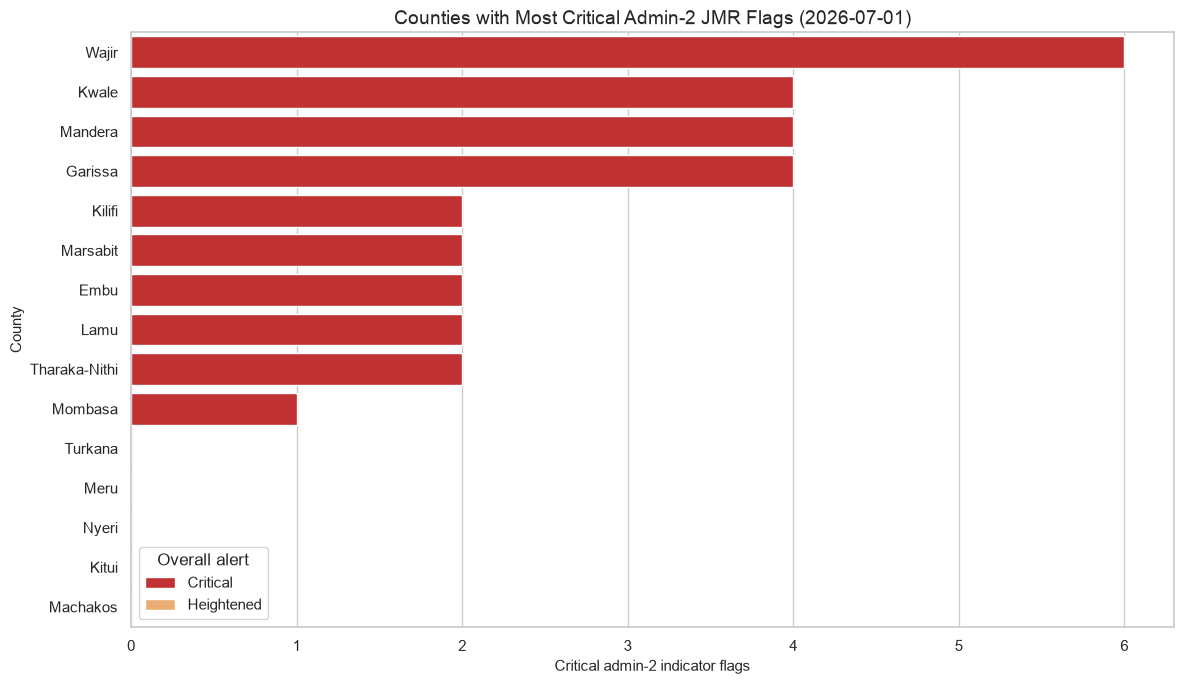

In [18]:
top_counties = county_risk_summary.head(15).copy()

plt.figure(figsize=(12, 7))
sns.barplot(
    data=top_counties,
    y="adm1_name",
    x="total_critical_admin2_flags",
    hue="overall_alert_label",
    dodge=False,
    palette={"Typical": "#7fbf7b", "Heightened": "#fdae61", "Critical": "#d7191c"},
)
plt.title(f"Counties with Most Critical Admin-2 JMR Flags ({latest_alert_date.date()})")
plt.xlabel("Critical admin-2 indicator flags")
plt.ylabel("County")
plt.legend(title="Overall alert")
plt.tight_layout()
plt.show()


In [28]:
print(heatmap_data.dtypes)

Conflict                      Int64
Drought - NDVI                Int64
Drought - rainfall            Int64
Exchange rates                Int64
Food prices                   Int64
Volatility - Exchange rate    Int64
Volatility - Food prices      Int64
dtype: object


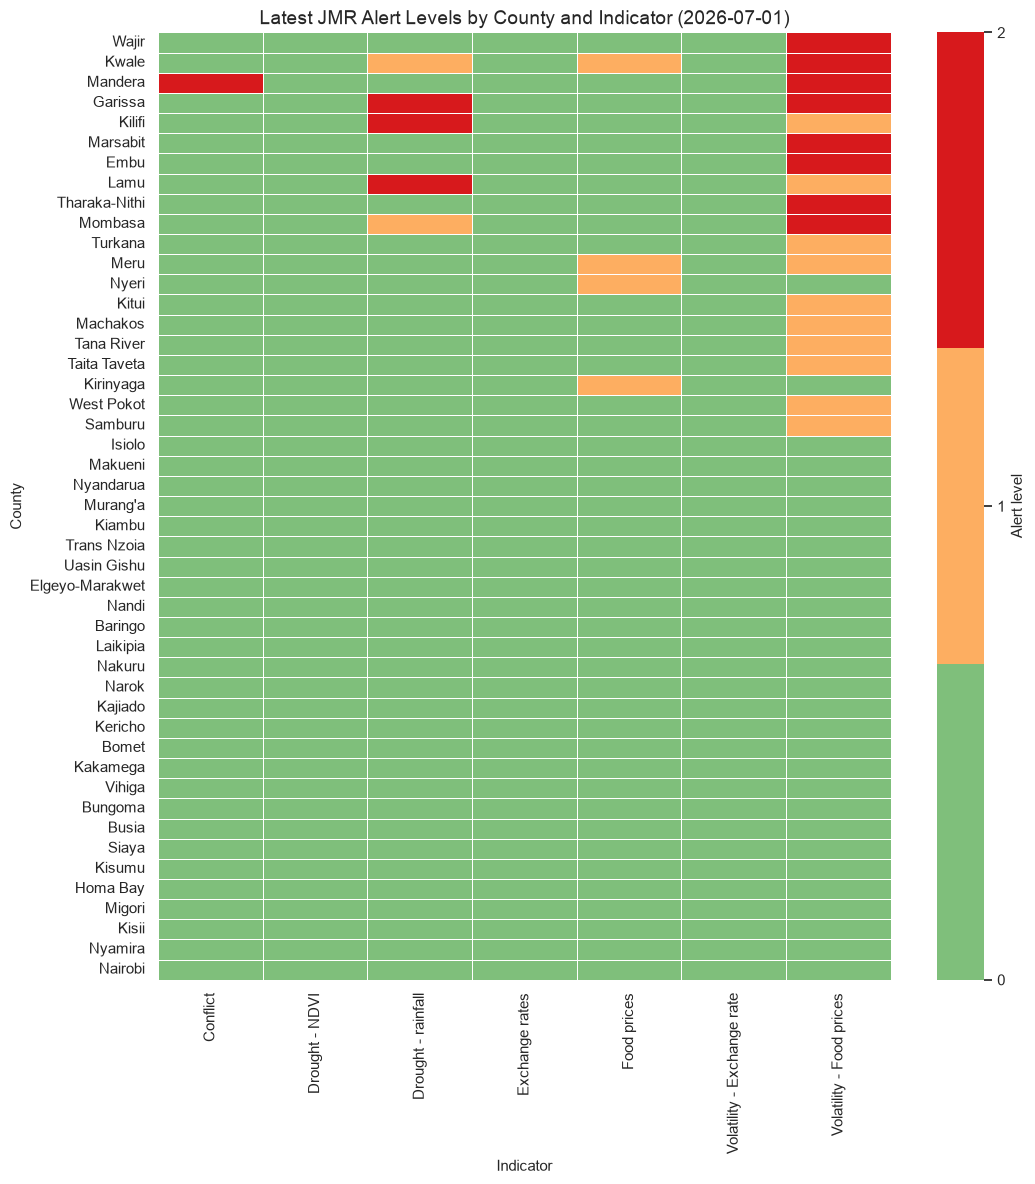

In [29]:
heatmap_data = county_indicator_matrix.set_index("adm1_name").drop(columns="adm1_pcode")
heatmap_data = heatmap_data.loc[county_risk_summary["adm1_name"]]
heatmap_data = heatmap_data.astype(float)

# 2. Plotting
plt.figure(figsize=(11, 12))
sns.heatmap(
    heatmap_data,
    cmap=sns.color_palette(["#7fbf7b", "#fdae61", "#d7191c"], as_cmap=True),
    vmin=0,
    vmax=2,
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"ticks": [0, 1, 2], "label": "Alert level"},
)
plt.title(f"Latest JMR Alert Levels by County and Indicator ({latest_alert_date.date()})")
plt.xlabel("Indicator")
plt.ylabel("County")
plt.tight_layout()
plt.show()

## 10. Join County Risk Data to GeoDataFrame

The county boundary GeoJSON has `ADM1_PCODE`; the JMR county table has `adm1_pcode`. This gives us a clean join key for a true county choropleth.


In [23]:
kenya_counties = gpd.read_file(SHAPEFILE_DIR / "kenya_counties.geojson").to_crs("EPSG:4326")
kenya_counties = kenya_counties.rename(columns={"ADM1_PCODE": "adm1_pcode", "ADM1_EN": "county_name"})

county_geo_df = kenya_counties.merge(county_risk_summary, on="adm1_pcode", how="left")
county_geo_df = gpd.GeoDataFrame(county_geo_df, geometry="geometry", crs=kenya_counties.crs)

print(county_geo_df.shape)
print("Counties without JMR data:", county_geo_df["overall_max_alert"].isna().sum())
display(county_geo_df[["county_name", "adm1_pcode", "overall_max_alert", "overall_alert_label"]].head())


(47, 84)
Counties without JMR data: 0


,county_name,adm1_pcode,overall_max_alert,overall_alert_label
0,Baringo,KE030,0,Typical
1,Bomet,KE036,0,Typical
2,Bungoma,KE039,0,Typical
3,Busia,KE040,0,Typical
4,Elgeyo-Marakwet,KE028,0,Typical


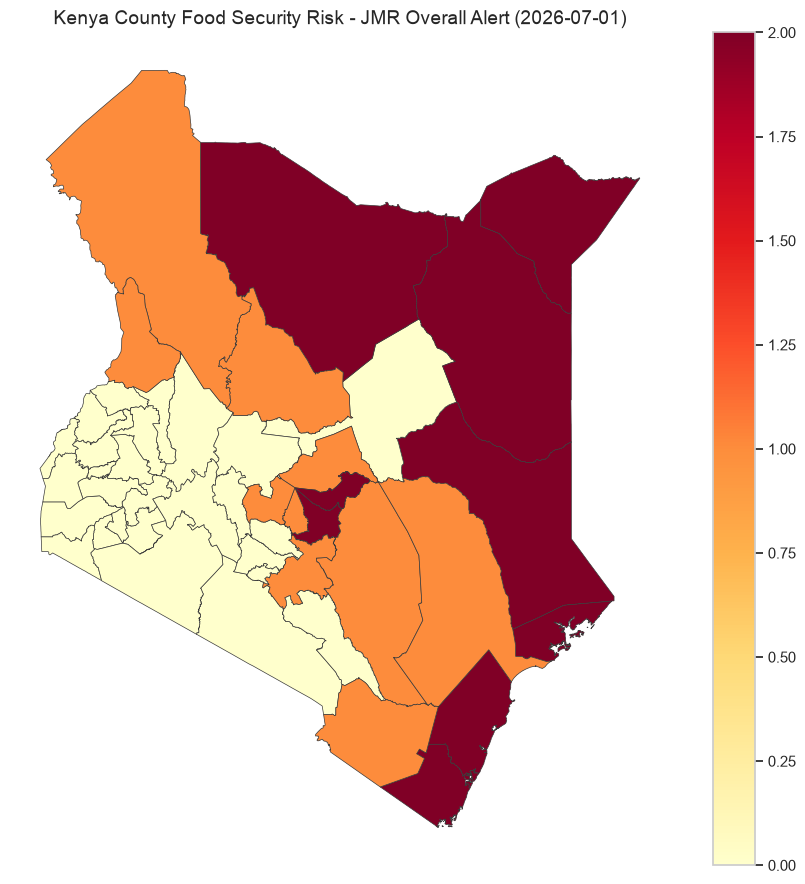

In [24]:
ax = county_geo_df.plot(
    column="overall_max_alert",
    cmap="YlOrRd",
    vmin=0,
    vmax=2,
    legend=True,
    edgecolor="#3a3a3a",
    linewidth=0.5,
    figsize=(9, 9),
    missing_kwds={"color": "#f0f0f0", "label": "No data"},
)
ax.set_title(f"Kenya County Food Security Risk - JMR Overall Alert ({latest_alert_date.date()})")
ax.set_axis_off()
plt.tight_layout()
plt.show()


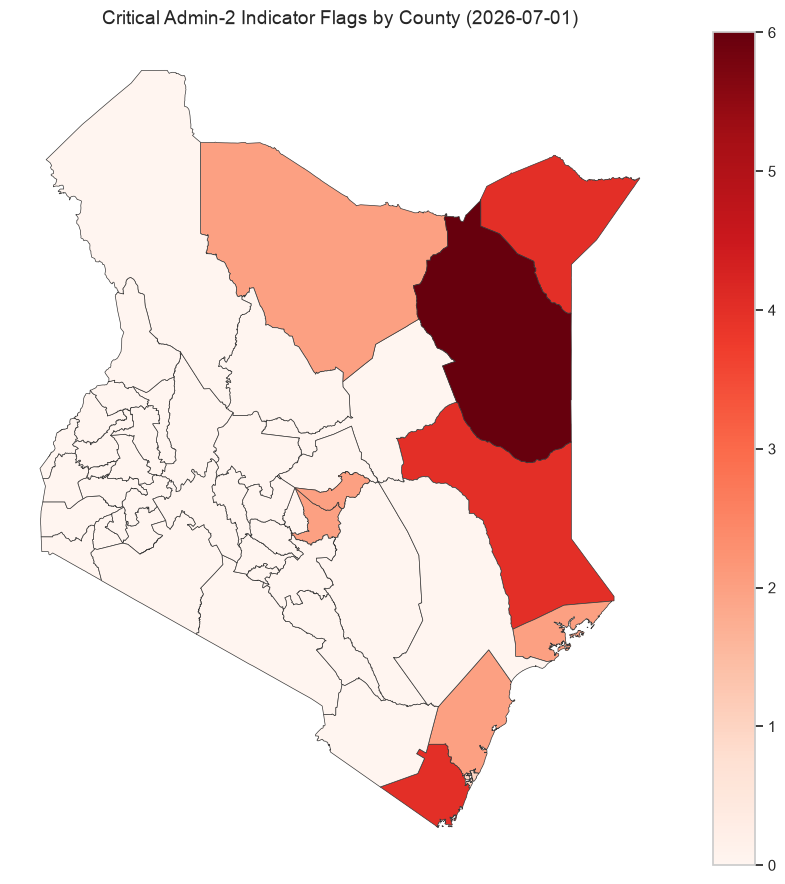

In [25]:
map_indicator = "total_critical_admin2_flags"

ax = county_geo_df.plot(
    column=map_indicator,
    cmap="Reds",
    legend=True,
    edgecolor="#3a3a3a",
    linewidth=0.5,
    figsize=(9, 9),
    missing_kwds={"color": "#f0f0f0", "label": "No data"},
)
ax.set_title(f"Critical Admin-2 Indicator Flags by County ({latest_alert_date.date()})")
ax.set_axis_off()
plt.tight_layout()
plt.show()


## 11. County Time Series Example

This example tracks a selected county over time. Change `selected_county` to explore another county.


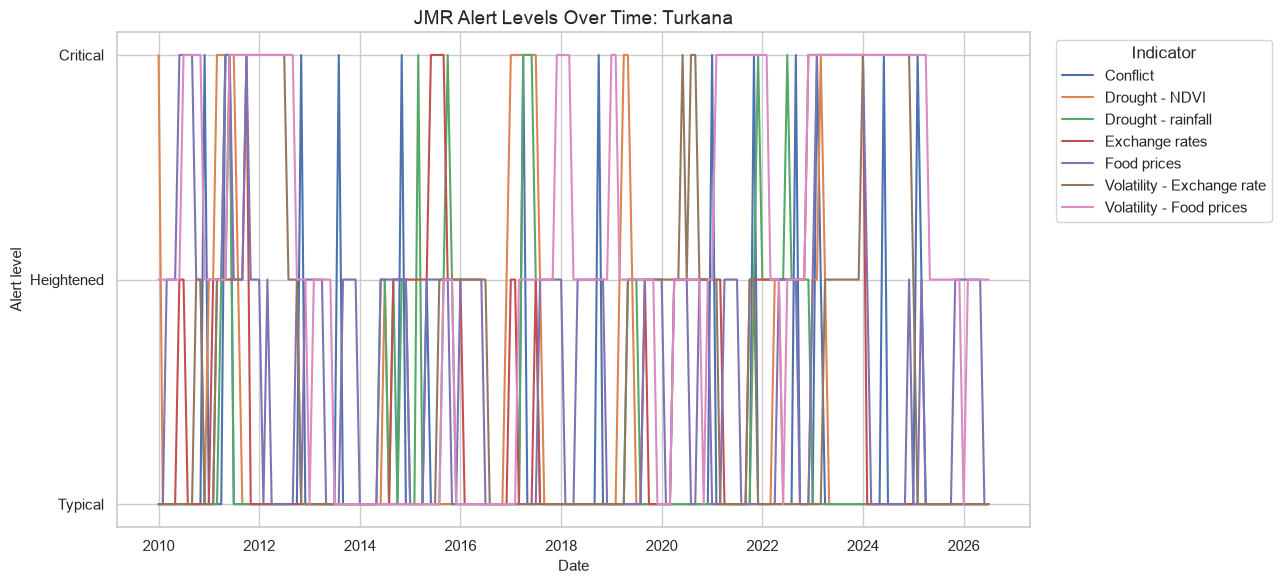

In [26]:
selected_county = "Turkana"

county_time = (
    county_alerts[county_alerts["adm1_name"].eq(selected_county)]
    .groupby(["date", "indicator"], as_index=False)
    .agg(max_alert_level=("max_alert_level", "max"))
)

plt.figure(figsize=(13, 6))
sns.lineplot(data=county_time, x="date", y="max_alert_level", hue="indicator")
plt.yticks([0, 1, 2], ["Typical", "Heightened", "Critical"])
plt.title(f"JMR Alert Levels Over Time: {selected_county}")
plt.xlabel("Date")
plt.ylabel("Alert level")
plt.legend(title="Indicator", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


## 12. What the Project Can Do Now

With the World Bank JMR data added, the project can now produce true county-level maps. The FAOSTAT data remains useful for national trends, while the JMR data supports county and sub-county risk analysis.

Useful outputs from this notebook:

1. `analysis_df`: national FAOSTAT trend table.
2. `jmr_admin`: JMR admin-2 table joined to county names and pcodes.
3. `county_risk_summary`: latest county-level risk summary.
4. `county_geo_df`: GeoPandas county layer joined to JMR risk metrics.
